In [1]:
from pathlib import Path

import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
from IPython.display import Image, display
from sklearn.decomposition import TruncatedSVD
from transformers import AutoModel, AutoTokenizer
from transformers.utils import logging

from utils.normalize import normalize_for_unit_mean
from utils.pooling import covariance_pooling, mean_pooling

/Users/h-tomo/Code/socm-text-embedding/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def _k_from_prob_2d(prob: float) -> float:
    # chi2(df=2): -2 ln(1-p)
    prob = min(max(float(prob), 1e-12), 1 - 1e-12)
    return float(np.sqrt(-2.0 * np.log(1.0 - prob)))


def _mean_cov(X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    t = torch.tensor(X, dtype=torch.float32)
    mask = torch.ones(t.shape[0], dtype=torch.float32)
    mu = mean_pooling(t, mask).numpy()
    cov = covariance_pooling(t, mask).numpy()
    return mu, cov


def _covariance_ellipse(mu, Sigma, k=1.0, num=240):
    vals, vecs = np.linalg.eigh(Sigma)
    vals = np.clip(vals, 0.0, None)
    M = vecs @ np.diag(np.sqrt(vals))
    t = np.linspace(0, 2 * np.pi, num=num, endpoint=True)
    circle = np.stack([np.cos(t), np.sin(t)], axis=0)
    ellipse = mu.reshape(2, 1) + k * (M @ circle)
    return ellipse[0], ellipse[1]


def _hex_to_rgba(hex_color: str, alpha: float = 0.45) -> str:
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"


def visualize_embeddings(
    texts: list[str],
    tokenizer: AutoTokenizer,
    model: AutoModel,
    width: int = 600,
    height: int = 400,
    save_filename: str = "figure.png",
    ellipse_prob: float = 0.75,
    x_range: list[float] | None = None,
    y_range: list[float] | None = None,
):
    model.eval()

    embeddings, labels, types = [], [], []
    with torch.no_grad():
        for idx, text in enumerate(texts, start=1):
            inputs = tokenizer([text], return_tensors="pt")
            last_hidden_states = model(**inputs).last_hidden_state
            normalized_states = normalize_for_unit_mean(
                last_hidden_states=last_hidden_states,
                attention_mask=inputs["attention_mask"],
            )

            for vec in normalized_states.squeeze(0).numpy():
                embeddings.append(vec)
                labels.append(f"Text_{idx}")
                types.append("token")

            mean_vec = (
                mean_pooling(normalized_states, inputs["attention_mask"])
                .squeeze(0)
                .numpy()
            )
            embeddings.append(mean_vec)
            labels.append(f"Text_{idx}")
            types.append("mean")

    # reduce to 2D
    stacked = np.vstack(embeddings)
    svd = TruncatedSVD(n_components=2, random_state=0)
    coords = svd.fit_transform(stacked)

    df = pl.DataFrame(
        {
            "PC1": coords[:, 0].tolist(),
            "PC2": coords[:, 1].tolist(),
            "Text": labels,
            "Type": types,
        }
    )

    palette = ["#2C77BA", "#BF8800"]
    color_map = {f"Text_{i+1}": palette[i % len(palette)] for i in range(len(texts))}

    k_ell = _k_from_prob_2d(ellipse_prob)

    fig = go.Figure()

    # ellipses
    for txt, base_hex in color_map.items():
        df_tok = df.filter((pl.col("Type") == "token") & (pl.col("Text") == txt))
        X2 = df_tok[["PC1", "PC2"]].to_numpy()
        mu2, Sigma2 = _mean_cov(X2)
        ex, ey = _covariance_ellipse(mu2, Sigma2, k=k_ell, num=240)

        fig.add_trace(
            go.Scatter(
                x=np.r_[ex, ex[:1]],
                y=np.r_[ey, ey[:1]],
                mode="lines",
                line=dict(width=0),
                fill="toself",
                fillcolor=base_hex,
                opacity=0.20,
                hoverinfo="skip",
                showlegend=False,
            )
        )
        fig.add_trace(
            go.Scatter(
                x=ex,
                y=ey,
                mode="lines",
                line=dict(width=2.1, color=base_hex),
                hoverinfo="skip",
                showlegend=False,
            )
        )

    # token embeddings
    for txt, base_hex in color_map.items():
        df_tok = df.filter((pl.col("Type") == "token") & (pl.col("Text") == txt))
        fig.add_trace(
            go.Scatter(
                x=df_tok["PC1"].to_list(),
                y=df_tok["PC2"].to_list(),
                mode="markers",
                marker=dict(
                    symbol="circle",
                    size=7,
                    color=_hex_to_rgba(base_hex, alpha=0.9),
                    line=dict(width=1.2, color="#DDDDDD"),
                ),
                showlegend=False,
                hoverinfo="skip",
            )
        )

    # text embeddings
    for txt, base_hex in color_map.items():
        df_mean = df.filter((pl.col("Type") == "mean") & (pl.col("Text") == txt))
        fig.add_trace(
            go.Scatter(
                x=df_mean["PC1"].to_list(),
                y=df_mean["PC2"].to_list(),
                mode="markers",
                marker=dict(
                    symbol="star",
                    size=21,
                    color=base_hex,
                    line=dict(width=1.2, color="#DDDDDD"),
                ),
                showlegend=False,
                hoverinfo="skip",
            )
        )

    fig.update_layout(
        showlegend=False,
        width=width,
        height=height,
        plot_bgcolor="rgba(0,0,0,0)",
        paper_bgcolor="rgba(0,0,0,0)",
        font=dict(size=24, family="Times New Roman, Arial"),
        margin=dict(l=1.5, r=1.5, t=1.5, b=1.5, pad=0),
    )

    fig.update_xaxes(
        range=x_range,
        showticklabels=False,
        showgrid=False,
        zeroline=False,
        showline=False,
    )
    fig.update_yaxes(
        range=y_range,
        showticklabels=False,
        showgrid=False,
        zeroline=False,
        showline=False,
    )

    save_path = Path(save_filename)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.write_image(str(save_path), format="png", width=width, height=height)
    display(Image(str(save_path)))
    # fig.write_image(str(save_path.with_suffix(".pdf")), format="pdf", width=width, height=height)
    # fig.show()

In [3]:
dataset_name = "wiki_1000"
text_df = pl.read_csv(f"../data/{dataset_name}.csv")
map_id2text = dict(zip(text_df["text_id"].to_list(), text_df["text"].to_list()))

text1_id = 335
text2_id = 739
text1 = map_id2text[text1_id]
text2 = map_id2text[text2_id]
print(f"text1: {text1}")
print(f"text2: {text2}")

text1: Virginia Woolf set many scenes of her novel "Night and Day" (1919) in Russell Square.
text2: Ghiz was born in Charlottetown, Prince Edward Island, to Atallah Joseph Ghiz, a Lebanese corner store owner, and Marguerite F. Ghiz (née McKarris).


In [4]:
logging.set_verbosity_error()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1616.26it/s, Materializing param=pooler.dense.weight]                               


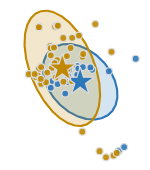

socm: 0.6116161942481995


In [5]:
model_name = "google-bert/bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

visualize_embeddings(
    [text1, text2],
    tokenizer,
    model,
    width=150,
    height=170,
    save_filename="./figs/qualitative_analysis/bert.png",
    x_range=[-1.5, -0.2],
    y_range=[-1.6, 1.1],
)

result_df = pl.read_csv(Path(f"../results/socm/{dataset_name}_google-bert-bert-base-uncased.csv"))
row = result_df.filter(
    ((pl.col("text1_id") == text1_id) & (pl.col("text2_id") == text2_id))
    | ((pl.col("text1_id") == text2_id) & (pl.col("text2_id") == text1_id))
)
# SOCM values may differ slightly from those reported in the paper due to differences in the computing environment used for the qualitative analysis, but these differences do not affect the conclusions.
print(f"socm: {row['socm'][0]}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1811.50it/s, Materializing param=pooler.dense.weight]                               


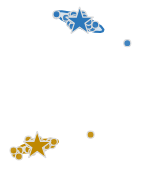

socm: 0.01704958640038967


In [6]:
model_name = "thenlper/gte-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

visualize_embeddings(
    [text1, text2],
    tokenizer,
    model,
    width=150,
    height=170,
    save_filename="./figs/qualitative_analysis/gte.png",
    x_range=[-1.06, -0.7],
    y_range=[-0.36, 0.61],
)

result_df = pl.read_csv(Path(f"../results/socm/{dataset_name}_thenlper-gte-base.csv"))
row = result_df.filter(
    ((pl.col("text1_id") == text1_id) & (pl.col("text2_id") == text2_id))
    | ((pl.col("text1_id") == text2_id) & (pl.col("text2_id") == text1_id))
)
print(f"socm: {row['socm'][0]}")